<a href="https://colab.research.google.com/github/senaegilmezbas-ui/DSA210-PROJECT/blob/main/DSA210.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#STEP 0: Upload Data
Data to be analyzed is uploaded.

In [4]:
from google.colab import files
uploaded = files.upload()

Saving Strava Activities.xlsx to Strava Activities.xlsx


#STEP 1: Setup and Data Loading

The analysis starts by importing the Python libraries used throughout the project. Pandas is used for data handling, matplotlib and seaborn for visualizations, and scipy for statistical analysis. After that, the Strava activity file is loaded into Python. Since the dataset covers runs recorded between 2017 and 2026, this step is mainly intended to make sure that the file is read correctly and that all observations are available before moving on to data cleaning and exploration.


In [5]:
#@title STEP 1: Import libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

df = pd.read_excel('Strava Activities.xlsx')

print(f"Dataset loaded successfully with {len(df)} total records.")

Dataset loaded successfully with 2858 total records.


#STEP 2: Data Cleaning

Before starting the analysis, the dataset was cleaned to remove records that were not suitable for the study. Since the original Strava export includes different activity types, only running activities were kept. Missing values in the main variables used for pace calculation were removed, and the activity date was converted into datetime format. A separate year variable was also created so that changes over time could be examined more clearly.

Next, pace was calculated in minutes per kilometer using moving time and distance. Because some activities may contain recording problems or unrealistic values, runs with extremely low or high pace values were excluded from the dataset. Finally, each run was assigned to a pre-COVID, COVID, or post-COVID period in order to support the comparison used in the first hypothesis.

In [6]:
#@title STEP 2

# Keep only running activities
df_runs = df[df['Activity Type'] == 'Run'].copy()

# Remove missing values in variables needed for pace calculation
df_runs = df_runs.dropna(subset=['Moving Time', 'Distance'])

# Convert dates and extract year information
df_runs['Activity Date'] = pd.to_datetime(df_runs['Activity Date'])
df_runs['Year'] = df_runs['Activity Date'].dt.year

# Calculate pace in minutes per kilometer
df_runs['Pace'] = (df_runs['Moving Time'] / 60) / df_runs['Distance']

# Remove unrealistic pace values
df_runs = df_runs[(df_runs['Pace'] > 3) & (df_runs['Pace'] < 12)]

# Create time periods for COVID-related comparison
def get_covid_period(year):
    if year <= 2019:
        return 'Pre-COVID'
    elif year <= 2021:
        return 'COVID'
    else:
        return 'Post-COVID'

df_runs['COVID_Period'] = df_runs['Year'].apply(get_covid_period)

# Create elevation groups based on median for later analysis and EDA
median_elev = df_runs['Elevation Gain'].median()
df_runs['Elevation_Group'] = df_runs['Elevation Gain'].apply(
    lambda x: 'High' if x > median_elev else 'Low'
)

print(f"After cleaning, {len(df_runs)} running activities remain for analysis.")

After cleaning, 2162 running activities remain for analysis.


#STEP 3: Exploratory Data Analysis (EDA)




## Exploratory Data Analysis (EDA)

Before conducting hypothesis testing, an exploratory data analysis is performed to understand the structure, distributions, and relationships within the dataset. This step helps ensure that the assumptions behind statistical tests are reasonable and provides initial insights into the data.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [8]:
#@title 3.1 Dataset Overview

print("Dataset shape:", df_runs.shape)
display(df_runs.head())
display(df_runs.info())
display(df_runs.describe())

Dataset shape: (2162, 32)


,Activity ID,Activity Date,Activity Name,Activity Type,Elapsed Time,Distance,Max Heart Rate,Relative Effort,Commute,Activity Gear,...,Average Cadence,Max Heart Rate.1,Average Heart Rate,Calories,Relative Effort.1,Commute.1,Year,Pace,COVID_Period,Elevation_Group
0,874167266,2017-02-21 05:40:48,Morning Run,Run,3994,11.10,160.0,67.0,False,NaN,...,89.0,160.0,128.0,NaN,67.0,0.0,2017,5.996997,Pre-COVID,Low
1,874447628,2017-02-11 11:58:24,Afternoon Run,Run,1423,4.06,150.0,24.0,False,NaN,...,88.0,150.0,127.0,NaN,24.0,0.0,2017,5.841544,Pre-COVID,Low
2,874447631,2017-01-31 10:36:55,Afternoon Run,Run,391,0.62,118.0,1.0,False,NaN,...,79.0,118.0,102.0,NaN,1.0,0.0,2017,10.510753,Pre-COVID,Low
3,874447638,2017-02-09 09:33:41,Lunch Run,Run,1652,5.96,225.0,88.0,False,NaN,...,79.0,225.0,155.0,NaN,88.0,0.0,2017,4.619687,Pre-COVID,Low
4,874447642,2017-01-21 13:15:57,Afternoon Run,Run,508,0.92,122.0,1.0,False,NaN,...,82.0,122.0,94.0,NaN,1.0,0.0,2017,8.894928,Pre-COVID,Low


<class 'pandas.core.frame.DataFrame'>
Index: 2162 entries, 0 to 2857
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Activity ID         2162 non-null   int64         
 1   Activity Date       2162 non-null   datetime64[ns]
 2   Activity Name       2161 non-null   object        
 3   Activity Type       2162 non-null   object        
 4   Elapsed Time        2162 non-null   int64         
 5   Distance            2162 non-null   float64       
 6   Max Heart Rate      2006 non-null   float64       
 7   Relative Effort     2006 non-null   float64       
 8   Commute             2162 non-null   bool          
 9   Activity Gear       602 non-null    object        
 10  Athlete Weight      980 non-null    float64       
 11  Bike Weight         0 non-null      float64       
 12  Moving Time         2162 non-null   int64         
 13  Max Speed           2158 non-null   float64       
 1

None

,Activity ID,Activity Date,Elapsed Time,Distance,Max Heart Rate,Relative Effort,Athlete Weight,Bike Weight,Moving Time,Max Speed,...,Average Grade,Max Cadence,Average Cadence,Max Heart Rate.1,Average Heart Rate,Calories,Relative Effort.1,Commute.1,Year,Pace
count,2.162000e+03,2162,2162.000000,2162.000000,2006.000000,2006.000000,980.000000,0.0,2162.000000,2158.000000,...,2162.000000,2148.000000,2149.000000,1181.000000,2006.000000,1915.000000,2004.000000,2047.000000,2162.000000,2162.000000
mean,5.946105e+09,2021-03-16 17:54:26.978260992,3864.446346,10.472983,154.114656,58.145065,69.537857,NaN,3816.008326,4.169877,...,-0.001850,97.231378,86.834342,158.606266,131.810568,739.154569,58.245010,0.000977,2020.721554,6.168214
min,8.741673e+08,2017-01-21 12:05:43,14.000000,0.030000,86.000000,0.000000,67.000000,NaN,13.000000,0.800000,...,-5.000000,58.000000,5.000000,87.000000,77.000000,1.000000,1.000000,0.000000,2017.000000,3.118280
25%,2.148022e+09,2019-02-13 20:17:37,2434.000000,6.462500,138.000000,17.000000,67.400000,NaN,2414.000000,3.500000,...,0.000000,94.000000,85.000000,141.000000,125.000000,469.000000,17.000000,0.000000,2019.000000,5.812041
50%,4.379078e+09,2020-11-23 09:54:05,3671.500000,10.090000,149.000000,38.000000,68.700000,NaN,3661.000000,4.000000,...,0.000000,97.000000,89.000000,153.000000,130.000000,693.000000,38.000000,0.000000,2020.000000,6.139434
75%,9.365185e+09,2023-06-30 21:57:19.249999872,4342.000000,12.120000,164.000000,78.000000,70.000000,NaN,4293.500000,4.600000,...,0.000000,99.000000,91.000000,168.000000,137.000000,860.000000,78.000000,0.000000,2023.000000,6.467391
max,1.789737e+10,2026-03-29 06:38:41,26884.000000,43.370000,254.000000,572.000000,75.800000,NaN,22026.000000,19.500000,...,4.700000,128.000000,95.000000,254.000000,208.000000,3724.000000,572.000000,1.000000,2026.000000,11.941392
std,4.611879e+09,NaN,2518.374176,6.471353,22.802805,62.490302,2.588650,NaN,2430.257283,1.210341,...,0.229633,6.240634,6.728889,25.957493,11.043645,458.253770,62.487857,0.031250,2.557110,0.837952


In [9]:
#@title 3.2 Missing Values

missing_values = df_runs.isnull().sum().sort_values(ascending=False)
display(missing_values[missing_values > 0])

,0
Bike Weight,2162
Activity Gear,1560
Athlete Weight,1182
Max Heart Rate.1,981
Average Speed,776
Elevation Loss,359
Calories,247
Relative Effort.1,158
Max Heart Rate,156
Relative Effort,156


In [10]:
#@title 3.3 Key Variables for EDA

eda_cols = ['Distance', 'Pace', 'Elevation Gain', 'Average Heart Rate']

df_runs[eda_cols].describe()

,Distance,Pace,Elevation Gain,Average Heart Rate
count,2162.000000,2162.000000,2152.000000,2006.000000
mean,10.472983,6.168214,55.709851,131.810568
std,6.471353,0.837952,88.002675,11.043645
min,0.030000,3.118280,0.000000,77.000000
25%,6.462500,5.812041,9.800000,125.000000
50%,10.090000,6.139434,24.700000,130.000000
75%,12.120000,6.467391,64.700000,137.000000
max,43.370000,11.941392,819.000000,208.000000


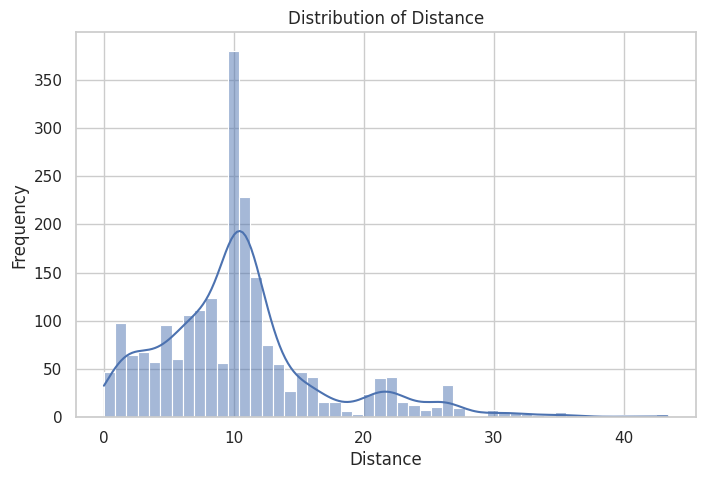

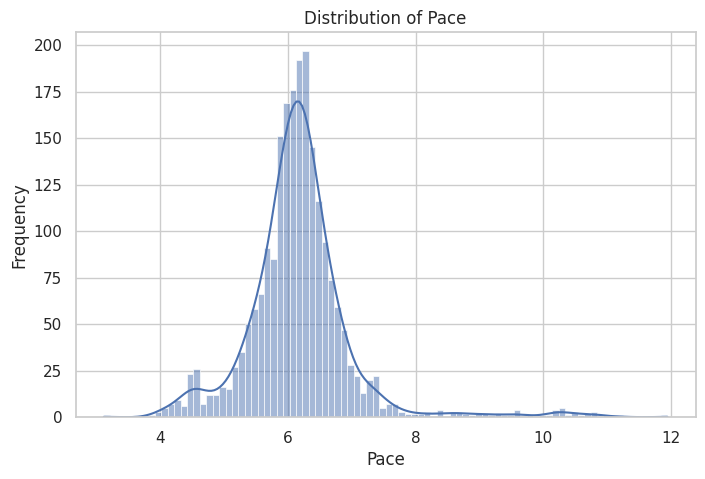

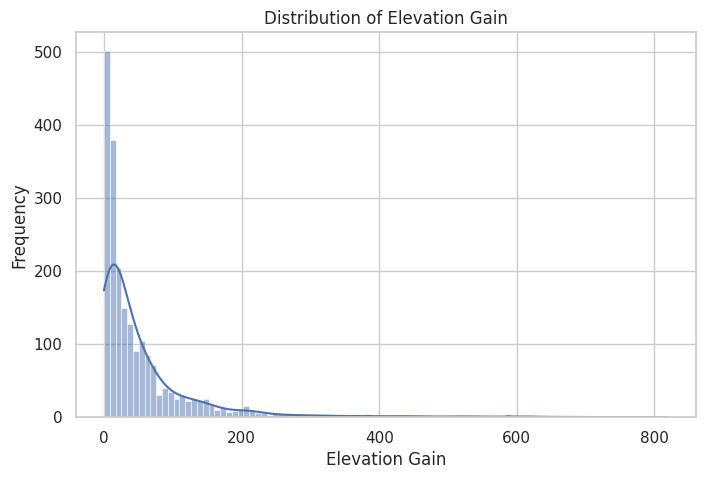

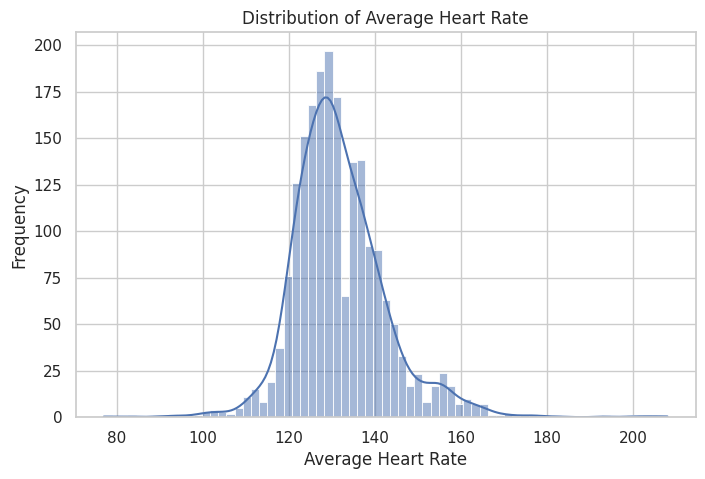

In [11]:
#@title 3.4 Distribution of Key Variables

for col in eda_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df_runs[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

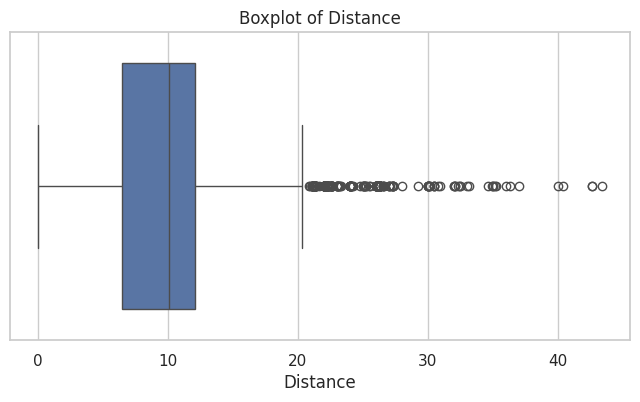

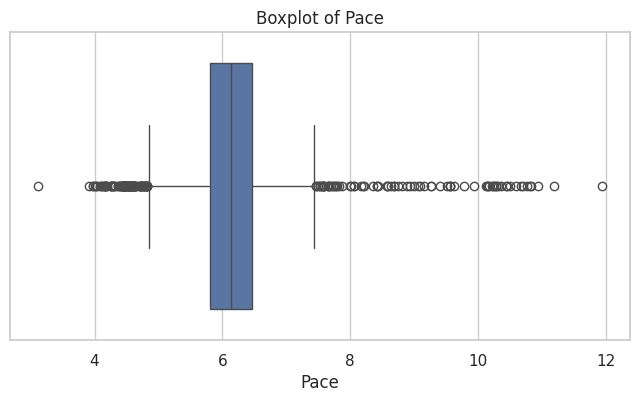

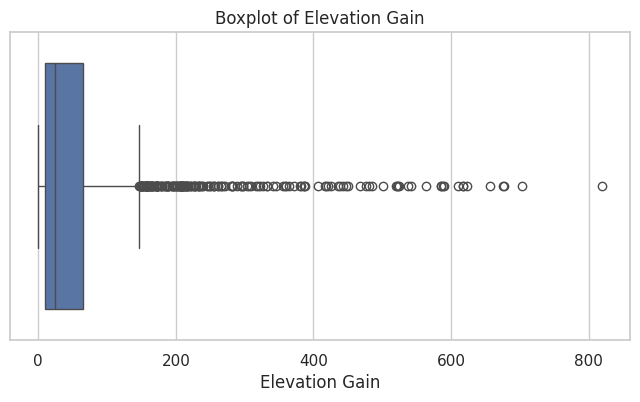

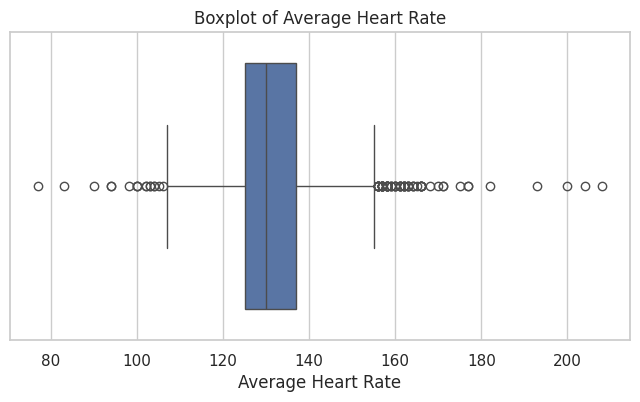

In [12]:
#@title 3.5 Boxplots for Outlier Detection

for col in eda_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_runs[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

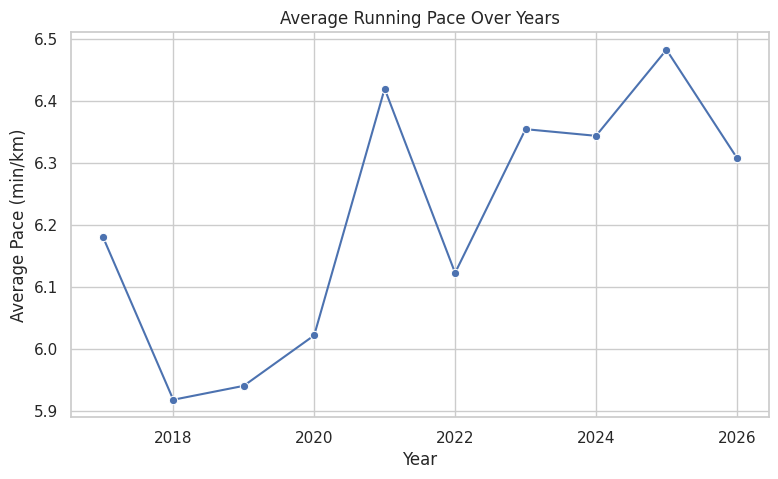

In [13]:
#@title 3.6 Average Pace Over Years

yearly_pace = df_runs.groupby('Year')['Pace'].mean()

plt.figure(figsize=(9, 5))
sns.lineplot(x=yearly_pace.index, y=yearly_pace.values, marker='o')
plt.title('Average Running Pace Over Years')
plt.xlabel('Year')
plt.ylabel('Average Pace (min/km)')
plt.show()

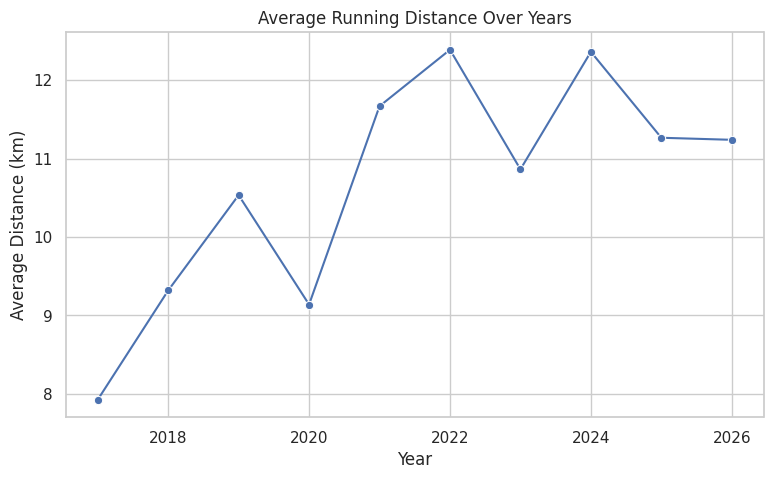

In [14]:
#@title 3.7 Average Distance Over Years

yearly_distance = df_runs.groupby('Year')['Distance'].mean()

plt.figure(figsize=(9, 5))
sns.lineplot(x=yearly_distance.index, y=yearly_distance.values, marker='o')
plt.title('Average Running Distance Over Years')
plt.xlabel('Year')
plt.ylabel('Average Distance (km)')
plt.show()

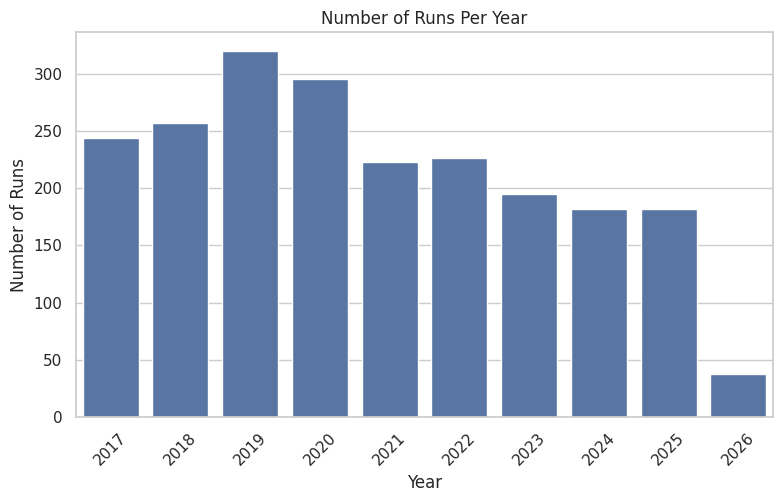

In [15]:
#@title 3.8 Number of Runs Per Year

runs_per_year = df_runs.groupby('Year').size()

plt.figure(figsize=(9, 5))
sns.barplot(x=runs_per_year.index, y=runs_per_year.values)
plt.title('Number of Runs Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Runs')
plt.xticks(rotation=45)
plt.show()

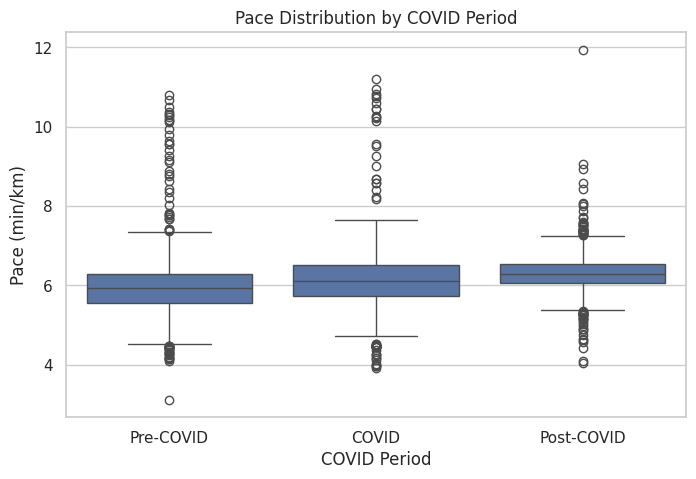

In [16]:
#@title 3.9 Pace Distribution by COVID Period

plt.figure(figsize=(8, 5))
sns.boxplot(x='COVID_Period', y='Pace', data=df_runs)
plt.title('Pace Distribution by COVID Period')
plt.xlabel('COVID Period')
plt.ylabel('Pace (min/km)')
plt.show()

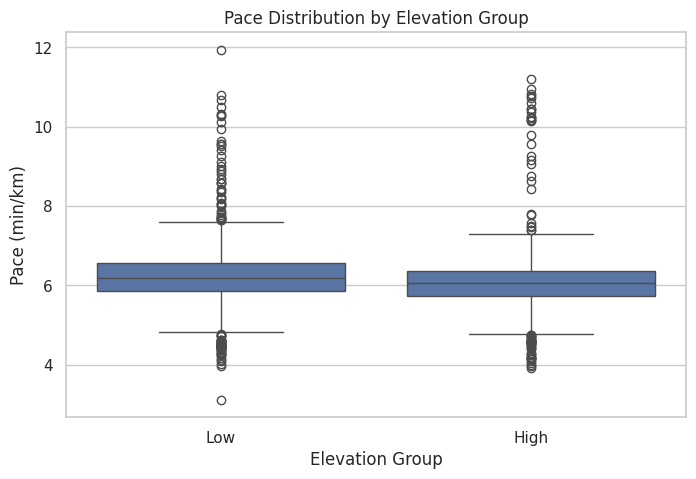

In [17]:
#@title 3.10 Pace Distribution by Elevation Group

plt.figure(figsize=(8, 5))
sns.boxplot(x='Elevation_Group', y='Pace', data=df_runs)
plt.title('Pace Distribution by Elevation Group')
plt.xlabel('Elevation Group')
plt.ylabel('Pace (min/km)')
plt.show()

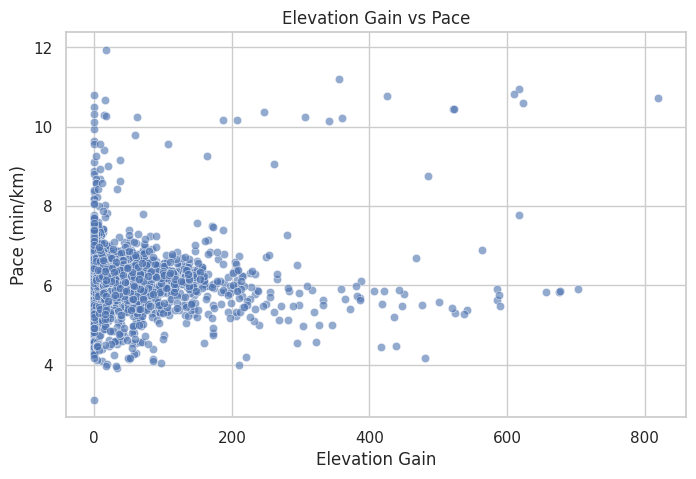

In [18]:
#@title 3.11 Relationship Between Elevation Gain and Pace

plt.figure(figsize=(8, 5))
sns.scatterplot(x='Elevation Gain', y='Pace', data=df_runs, alpha=0.6)
plt.title('Elevation Gain vs Pace')
plt.xlabel('Elevation Gain')
plt.ylabel('Pace (min/km)')
plt.show()

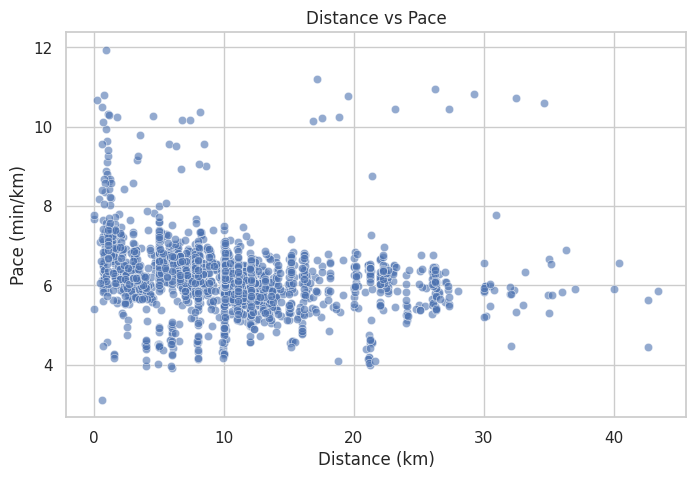

In [19]:
#@title 3.12 Relationship Between Distance and Pace

plt.figure(figsize=(8, 5))
sns.scatterplot(x='Distance', y='Pace', data=df_runs, alpha=0.6)
plt.title('Distance vs Pace')
plt.xlabel('Distance (km)')
plt.ylabel('Pace (min/km)')
plt.show()

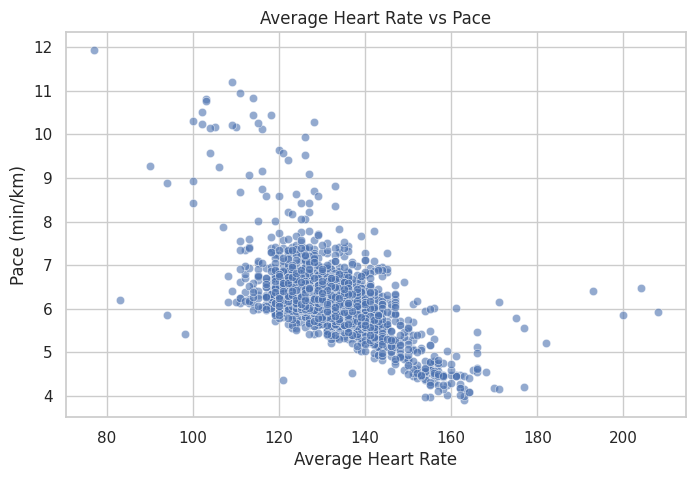

In [20]:
#@title 3.13 Relationship Between Average Heart Rate and Pace

plt.figure(figsize=(8, 5))
sns.scatterplot(x='Average Heart Rate', y='Pace', data=df_runs, alpha=0.6)
plt.title('Average Heart Rate vs Pace')
plt.xlabel('Average Heart Rate')
plt.ylabel('Pace (min/km)')
plt.show()

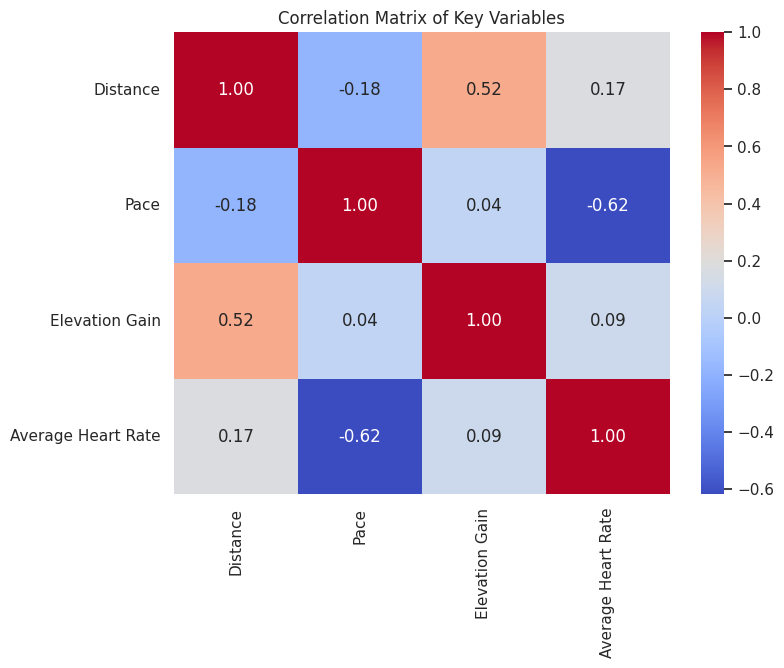

In [21]:
#@title 3.14 Correlation Matrix

corr = df_runs[eda_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt="-.2f")
plt.title('Correlation Matrix of Key Variables')
plt.show()

## EDA Interpretation

The exploratory data analysis provides a comprehensive overview of the dataset before conducting statistical tests.

The distribution plots indicate that pace values are generally concentrated within a reasonable range, with a slight right skew, suggesting occasional slower runs. Distance and elevation gain distributions show variability in training conditions, while heart rate appears relatively stable.

Boxplots reveal the presence of some outliers, particularly in pace and elevation, which is expected in real-world running data due to variations in training intensity and terrain.

The time series analysis suggests that running performance has fluctuated over the years, with some noticeable changes during the COVID-19 period. This provides an initial visual indication supporting the hypothesis regarding pandemic-related performance differences.

Comparisons across COVID periods and elevation groups show visible differences in pace distributions, justifying the use of statistical tests such as t-tests in the next section.

Scatter plots and the correlation matrix indicate weak to moderate relationships between variables. In particular, elevation gain appears to have a positive relationship with pace (slower runs), while distance and heart rate show less consistent patterns.

Overall, the EDA highlights key patterns, variability, and potential relationships in the data, forming a solid foundation for the hypothesis testing and machine learning steps that follow.

#STEP 4: Hypothesis 1 – COVID-19 and Running Pace

Hypothesis

H0: There is no difference in average running pace between the COVID-19 period (2020–2021) and the pre/post-pandemic periods.  
H1: There is a difference in average running pace between the COVID-19 period (2020–2021) and the pre/post-pandemic periods.  

Expected Direction: It is expected that running pace may have become slower during the COVID-19 period due to changes in training conditions.

This part of the analysis focuses on the first hypothesis, which examines whether running pace changed during the COVID-19 period. In this analysis, pace is measured in minutes per kilometer, meaning that higher values indicate slower running performance.

To explore this, a box plot is first used to compare the distribution of pace values across the pre-COVID, COVID, and post-COVID periods. The box plot makes it easier to observe differences in median pace as well as the overall spread and variability in each period.

After this visual comparison, an independent samples t-test is performed to directly compare the pre-COVID and COVID groups. The goal is to determine whether the difference in average pace between these two periods is statistically significant.

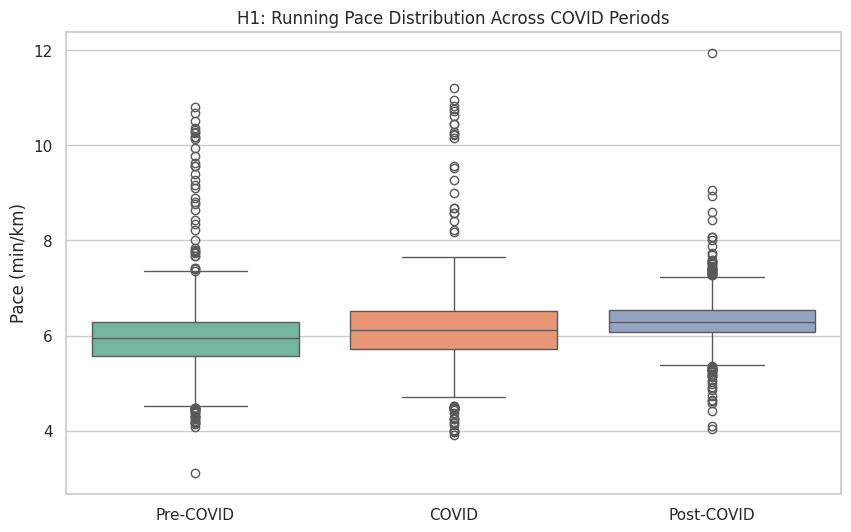

H1 Results: T-statistic = -3.4134, P-value = 0.0007
Conclusion: The difference in average pace between the pre-COVID and COVID periods is statistically significant.


In [22]:
#@title STEP 4

# Box plot of pace across COVID periods
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_runs,
    x='COVID_Period',
    y='Pace',
    order=['Pre-COVID', 'COVID', 'Post-COVID'],
    hue='COVID_Period',
    dodge=False,
    palette='Set2',
    legend=False
)
plt.title('H1: Running Pace Distribution Across COVID Periods')
plt.ylabel('Pace (min/km)')
plt.xlabel('')
plt.show()

# Independent samples t-test: Pre-COVID vs COVID
group_pre = df_runs[df_runs['COVID_Period'] == 'Pre-COVID']['Pace']
group_covid = df_runs[df_runs['COVID_Period'] == 'COVID']['Pace']

t_stat, p_val = stats.ttest_ind(group_pre, group_covid, equal_var=False, nan_policy='omit')
print(f"H1 Results: T-statistic = {t_stat:.4f}, P-value = {p_val:.4f}")

if p_val < 0.05:
    print("Conclusion: The difference in average pace between the pre-COVID and COVID periods is statistically significant.")
else:
    print("Conclusion: No statistically significant difference was found between the pre-COVID and COVID periods.")

Interpretation of Results

The results suggest that average pace increased slightly during the COVID period compared to the pre-COVID period. Since pace is measured in minutes per kilometer, this indicates a small decline in running performance. Although the difference is relatively modest, the t-test results show that it is statistically significant.

The observed changes in pace may also reflect differences in training composition (e.g., more easy or long runs) rather than a pure decline in performance, which should be considered when interpreting the results.

#STEP 5: Hypothesis 2 – Elevation and Running Pace

Hypothesis

H0: There is no difference in running pace between runs with low elevation gain and runs with high elevation gain.  
H1: There is a difference in running pace between runs with low elevation gain and runs with high elevation gain.

Expected Direction: Runs with higher elevation are expected to result in slower pace values due to increased physical demand.

This part of the analysis examines the second hypothesis, which focuses on the relationship between elevation gain and running pace. Since pace is measured in minutes per kilometer, higher values indicate slower performance.

To explore this relationship, a scatter plot is used to visualize how pace changes with increasing elevation gain. In addition, the activities are divided into two groups based on the median elevation gain (low and high elevation) to allow for a more direct comparison.

An independent samples t-test is then used to compare the average pace between these two groups and determine whether any observed difference is statistically significant.

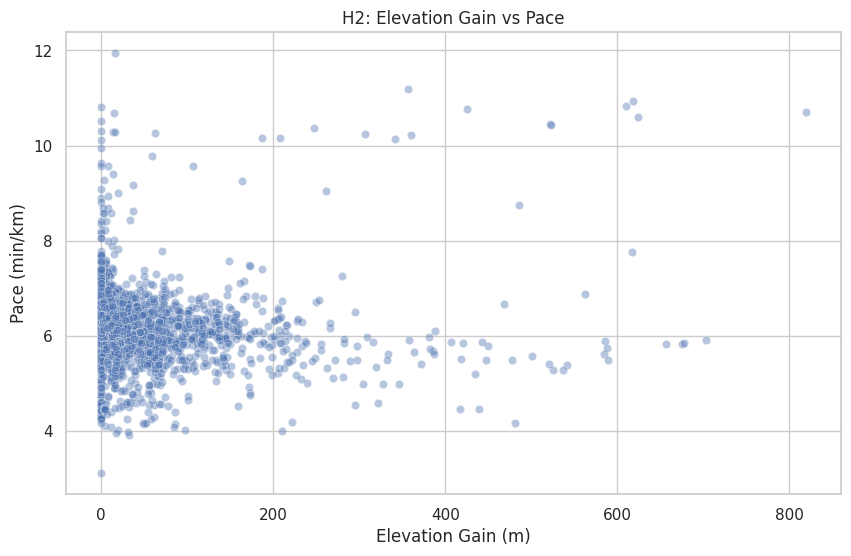

H2 Results: T-statistic = 4.4886, P-value = 0.0000
Conclusion: The difference between low and high elevation runs is statistically significant.


In [23]:
#@title STEP 5

# Create elevation groups based on median
median_elev = df_runs['Elevation Gain'].median()
df_runs['Elevation_Group'] = df_runs['Elevation Gain'].apply(
    lambda x: 'High' if x > median_elev else 'Low'
)

# Scatter plot: Elevation vs Pace
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_runs,
    x='Elevation Gain',
    y='Pace',
    alpha=0.4
)
plt.title('H2: Elevation Gain vs Pace')
plt.xlabel('Elevation Gain (m)')
plt.ylabel('Pace (min/km)')
plt.show()

# T-test: Low vs High elevation
low_elev = df_runs[df_runs['Elevation_Group'] == 'Low']['Pace']
high_elev = df_runs[df_runs['Elevation_Group'] == 'High']['Pace']

t_stat_e, p_val_e = stats.ttest_ind(low_elev, high_elev, equal_var=False, nan_policy='omit')
print(f"H2 Results: T-statistic = {t_stat_e:.4f}, P-value = {p_val_e:.4f}")

if p_val_e < 0.05:
    print("Conclusion: The difference between low and high elevation runs is statistically significant.")
else:
    print("Conclusion: No statistically significant difference was found between low and high elevation runs.")

Interpretation of Results

The results indicate that runs with higher elevation tend to result in slightly slower paces. Although the relationship is not very strong, the t-test results show that the difference between low and high elevation runs is statistically significant.

The observed relationship between elevation and pace may partly explain the differences seen in the previous analysis, as runs with higher elevation tend to result in slightly slower paces.

#STEP 6: Hypothesis 3 – Aging and Running Performance

Hypothesis

H0: There is no relationship between year and running pace.  
H1: There is a relationship between year and running pace.

Expected Direction: It is expected that running performance may decline slightly over time due to aging effects.

This part of the analysis examines the third hypothesis, which focuses on how running performance has changed over time. Since the dataset spans multiple years, it allows for a longitudinal analysis of performance trends.

To explore this relationship, a scatter plot with a regression line is used to visualize how running pace changes over time. This approach allows us to observe the overall trend while also preserving the variability across individual runs.

Additionally, a Pearson correlation test is conducted to measure the strength and direction of the relationship between year and pace, and to determine whether the observed trend is statistically significant.

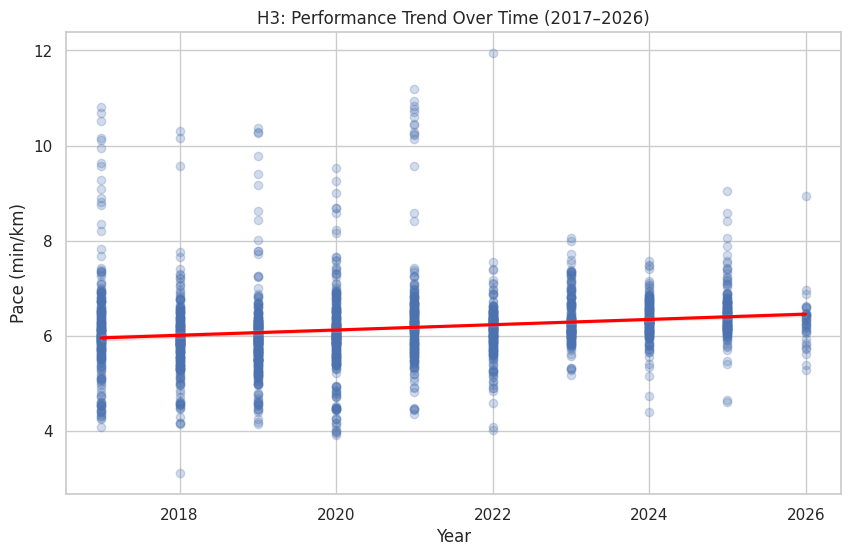

H3 Results: Pearson Correlation = 0.1692, P-value = 0.0000
Conclusion: There is a statistically significant relationship between year and pace.


In [24]:
#@title STEP 6

# Scatter plot with regression line
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_runs,
    x='Year',
    y='Pace',
    scatter_kws={'alpha': 0.25},
    line_kws={'color': 'red'}
)

plt.title('H3: Performance Trend Over Time (2017–2026)')
plt.xlabel('Year')
plt.ylabel('Pace (min/km)')
plt.show()

# Pearson correlation
corr, p_val_corr = stats.pearsonr(df_runs['Year'], df_runs['Pace'])
print(f"H3 Results: Pearson Correlation = {corr:.4f}, P-value = {p_val_corr:.4f}")

if p_val_corr < 0.05:
    print("Conclusion: There is a statistically significant relationship between year and pace.")
else:
    print("Conclusion: No statistically significant relationship was found between year and pace.")

Interpretation of Results

The results indicate a weak positive relationship between year and running pace, suggesting that pace has slightly increased over time. Since pace is measured in minutes per kilometer, this implies a small decline in running performance.

Although the correlation is relatively weak, the Pearson correlation test shows that the relationship is statistically significant. This suggests that the observed trend is unlikely to be due to random variation.

However, this trend may also reflect changes in training patterns, intensity, or running conditions over the years, rather than a pure effect of aging alone.

#STEP 7: Hypothesis 4 - Cardiovascular Efficiency

H0: There is no relationship between weekly training frequency and average heart rate.  
H1: There is a relationship between weekly training frequency and average heart rate.

Expected Direction: Higher training frequency is expected to be associated with lower average heart rate, indicating improved cardiovascular efficiency.

This part of the analysis examines the relationship between training frequency and cardiovascular efficiency.

To approximate training frequency, the number of runs per week is calculated. This is then compared with the athlete’s average heart rate to explore whether increased training frequency is associated with improved physiological adaptation.

A correlation matrix is used to examine the relationships between weekly training frequency, heart rate, pace, and distance, providing a broader view of how these variables interact.

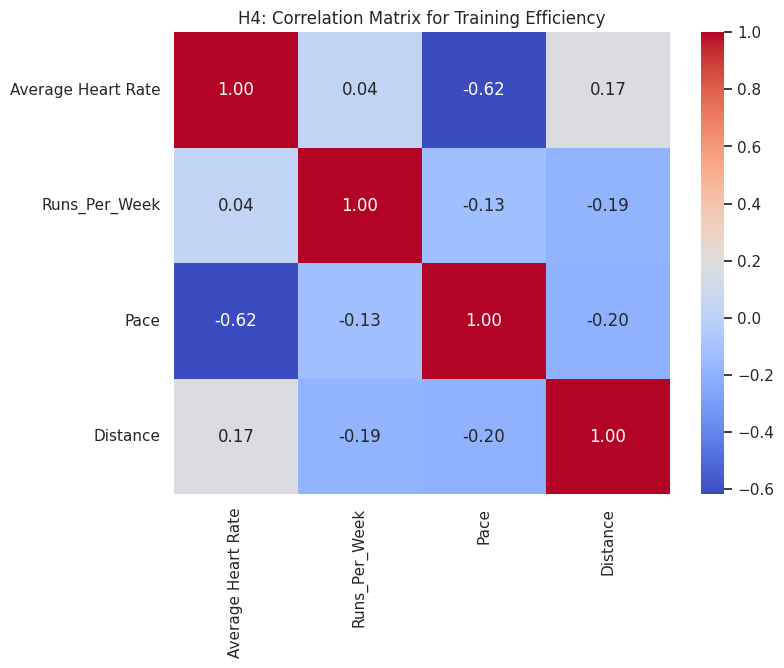

H4 Results: Correlation = 0.0357, P-value = 0.1102
Conclusion: No statistically significant relationship was found between training frequency and heart rate.


In [25]:
#@title STEP 7

# Create weekly identifier
df_runs['Week'] = df_runs['Activity Date'].dt.isocalendar().week
df_runs['Year_Week'] = df_runs['Year'].astype(str) + "-" + df_runs['Week'].astype(str)

# Calculate runs per week (training frequency)
weekly_freq = df_runs.groupby('Year_Week').size().reset_index(name='Runs_Per_Week')

# Merge back to main dataset
df_hr = df_runs.merge(weekly_freq, on='Year_Week')

# Select relevant variables and drop missing values
hr_analysis = df_hr[['Average Heart Rate', 'Runs_Per_Week', 'Pace', 'Distance']].dropna()

# Compute correlation matrix
corr_matrix = hr_analysis.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('H4: Correlation Matrix for Training Efficiency')
plt.show()

# Pearson correlation test (Runs per week vs Heart Rate)
corr_hr, p_val_hr = stats.pearsonr(
    hr_analysis['Runs_Per_Week'],
    hr_analysis['Average Heart Rate']
)

print(f"H4 Results: Correlation = {corr_hr:.4f}, P-value = {p_val_hr:.4f}")

if p_val_hr < 0.05:
    print("Conclusion: There is a statistically significant relationship between training frequency and heart rate.")
else:
    print("Conclusion: No statistically significant relationship was found between training frequency and heart rate.")

Conclusion

This study analyzed the impact of multiple factors on running performance over a 9-year period. The results indicate that performance is influenced by a combination of temporal, environmental, and physiological variables.

A statistically significant difference in pace was observed during the COVID-19 period, suggesting that external conditions may have affected training outcomes. Elevation was also found to have a significant effect, with higher elevation runs associated with slightly slower paces.

In addition, a weak but significant trend over time suggests that performance may have changed gradually, although this cannot be attributed solely to aging. Finally, no meaningful relationship was found between training frequency and heart rate, indicating that frequency alone is not sufficient to explain cardiovascular efficiency.

Overall, the findings suggest that running performance is multifactorial and should be interpreted within the broader context of training conditions, environmental factors, and workout composition.

Limitations

This analysis has several limitations.

First, the dataset includes different types of runs (e.g., long runs, easy runs, and high-intensity sessions), which may affect pace independently of the variables analyzed.

Second, elevation gain was used as a proxy for terrain difficulty, which may not fully capture environmental differences such as surface type or weather conditions.

Third, training frequency was measured as the number of runs per week, which does not account for training intensity or recovery.

Finally, the dataset represents a single athlete, which limits the generalizability of the findings.

In [26]:
#@title Create Sample Dataset for GitHub

# Take a random sample
df_sample = df_runs.sample(200, random_state=42).copy()

# Remove potentially sensitive columns (if they exist)
df_sample = df_sample.drop(
    columns=['Activity Name', 'Activity Date'],
    errors='ignore'
)

# Save as CSV
df_sample.to_csv("sample_data.csv", index=False)

print("Sample dataset created successfully: sample_data.csv")

Sample dataset created successfully: sample_data.csv


# STEP 8: MACHINE LEARNING


In [27]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

sns.set(style="whitegrid")

In [28]:
# 8.1 Prepare ML Dataset


df_ml = df_runs.copy()

# Remove rows with missing values in key ML columns
ml_required_cols = [
    'Distance',
    'Elevation Gain',
    'Average Heart Rate',
    'Year',
    'Pace',
    'COVID_Period',
    'Elevation_Group'
]

df_ml = df_ml.dropna(subset=ml_required_cols)

# Avoid division by zero
df_ml = df_ml[df_ml['Distance'] > 0]

print("ML dataset shape:", df_ml.shape)
df_ml.head()

ML dataset shape: (2000, 34)


,Activity ID,Activity Date,Activity Name,Activity Type,Elapsed Time,Distance,Max Heart Rate,Relative Effort,Commute,Activity Gear,...,Average Heart Rate,Calories,Relative Effort.1,Commute.1,Year,Pace,COVID_Period,Elevation_Group,Week,Year_Week
0,874167266,2017-02-21 05:40:48,Morning Run,Run,3994,11.10,160.0,67.0,False,NaN,...,128.0,NaN,67.0,0.0,2017,5.996997,Pre-COVID,Low,8,2017-8
1,874447628,2017-02-11 11:58:24,Afternoon Run,Run,1423,4.06,150.0,24.0,False,NaN,...,127.0,NaN,24.0,0.0,2017,5.841544,Pre-COVID,Low,6,2017-6
2,874447631,2017-01-31 10:36:55,Afternoon Run,Run,391,0.62,118.0,1.0,False,NaN,...,102.0,NaN,1.0,0.0,2017,10.510753,Pre-COVID,Low,5,2017-5
3,874447638,2017-02-09 09:33:41,Lunch Run,Run,1652,5.96,225.0,88.0,False,NaN,...,155.0,NaN,88.0,0.0,2017,4.619687,Pre-COVID,Low,6,2017-6
4,874447642,2017-01-21 13:15:57,Afternoon Run,Run,508,0.92,122.0,1.0,False,NaN,...,94.0,NaN,1.0,0.0,2017,8.894928,Pre-COVID,Low,3,2017-3


In [29]:
# 8.2 Feature Engineering


df_ml['HR_per_km'] = df_ml['Average Heart Rate'] / df_ml['Distance']
df_ml['Elevation_per_km'] = df_ml['Elevation Gain'] / df_ml['Distance']

df_ml['Distance_x_Elevation'] = df_ml['Distance'] * df_ml['Elevation Gain']
df_ml['Distance_x_HR'] = df_ml['Distance'] * df_ml['Average Heart Rate']
df_ml['Elevation_x_HR'] = df_ml['Elevation Gain'] * df_ml['Average Heart Rate']

# One-hot encode categorical variables
df_ml = pd.get_dummies(
    df_ml,
    columns=['COVID_Period', 'Elevation_Group'],
    drop_first=True
)

df_ml.head()

,Activity ID,Activity Date,Activity Name,Activity Type,Elapsed Time,Distance,Max Heart Rate,Relative Effort,Commute,Activity Gear,...,Week,Year_Week,HR_per_km,Elevation_per_km,Distance_x_Elevation,Distance_x_HR,Elevation_x_HR,COVID_Period_Post-COVID,COVID_Period_Pre-COVID,Elevation_Group_Low
0,874167266,2017-02-21 05:40:48,Morning Run,Run,3994,11.10,160.0,67.0,False,NaN,...,8,2017-8,11.531532,0.972973,119.88,1420.80,1382.4,False,True,True
1,874447628,2017-02-11 11:58:24,Afternoon Run,Run,1423,4.06,150.0,24.0,False,NaN,...,6,2017-6,31.280788,0.000000,0.00,515.62,0.0,False,True,True
2,874447631,2017-01-31 10:36:55,Afternoon Run,Run,391,0.62,118.0,1.0,False,NaN,...,5,2017-5,164.516129,0.000000,0.00,63.24,0.0,False,True,True
3,874447638,2017-02-09 09:33:41,Lunch Run,Run,1652,5.96,225.0,88.0,False,NaN,...,6,2017-6,26.006711,0.000000,0.00,923.80,0.0,False,True,True
4,874447642,2017-01-21 13:15:57,Afternoon Run,Run,508,0.92,122.0,1.0,False,NaN,...,3,2017-3,102.173913,0.000000,0.00,86.48,0.0,False,True,True


### 8.3 Define Features and Target

In [30]:
# Define features (X) and target (y)
features = ['Distance', 'Elevation Gain', 'Average Heart Rate', 'Year', 'HR_per_km', 'Elevation_per_km', 'Distance_x_Elevation', 'Distance_x_HR', 'Elevation_x_HR', 'COVID_Period_Post-COVID', 'COVID_Period_Pre-COVID', 'Elevation_Group_Low']
target = 'Pace'

X = df_ml[features]
y = df_ml[target]

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Features (X) shape: (2000, 12)
Target (y) shape: (2000,)


### 8.4 Split Data into Training and Testing Sets

In [31]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1600, 12)
X_test shape: (400, 12)
y_train shape: (1600,)
y_test shape: (400,)


### 8.5 Train a Random Forest Regressor Model

In [32]:
# Initialize and train a Random Forest Regressor model
model = RandomForestRegressor(
    n_estimators=100,  # Number of trees in the forest
    random_state=42    # For reproducibility
)

model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


### 8.6 Make Predictions on the Test Set

In [33]:
# Make predictions on the test set
y_pred = model.predict(X_test)

print("Predictions made.")

Predictions made.


### 8.7 Evaluate the Model Performance

In [34]:
# Evaluate the model performance using MAE, RMSE, and R-squared
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Absolute Error (MAE): 0.2552
Root Mean Squared Error (RMSE): 0.4070
R-squared (R2): 0.6584


### 8.8 Visualize Actual vs Predicted Pace

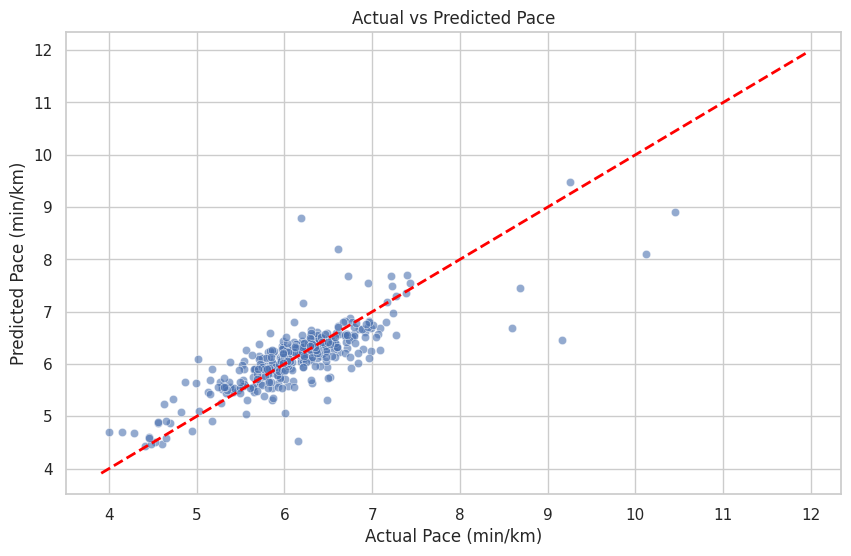

In [35]:
# Plot actual vs predicted pace values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', lw=2)
plt.title('Actual vs Predicted Pace')
plt.xlabel('Actual Pace (min/km)')
plt.ylabel('Predicted Pace (min/km)')
plt.grid(True)
plt.show()

### 8.9 Analyze Feature Importance

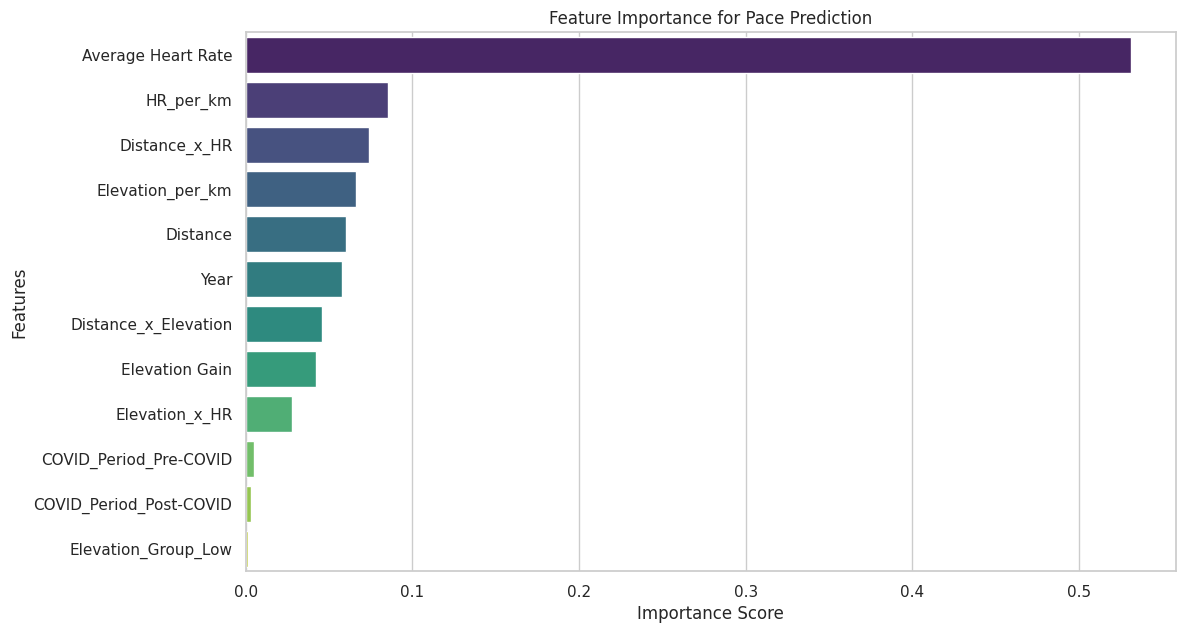

Feature Importance:
 Average Heart Rate         0.531410
HR_per_km                  0.085199
Distance_x_HR              0.073789
Elevation_per_km           0.066005
Distance                   0.060440
Year                       0.057939
Distance_x_Elevation       0.045888
Elevation Gain             0.041977
Elevation_x_HR             0.027654
COVID_Period_Pre-COVID     0.004787
COVID_Period_Post-COVID    0.003422
Elevation_Group_Low        0.001489
dtype: float64


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get and visualize feature importance
feature_importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='viridis', hue=feature_importance.index, legend=False)
plt.title('Feature Importance for Pace Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

print("Feature Importance:\n", feature_importance)

# STEP 9: Model Comparison

In this step, different regression models are trained and compared to see which one predicts running pace most accurately. Three models are tested: Linear Regression, Decision Tree, and Random Forest.

In [37]:
#@title STEP 9: Model Comparison

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Use the same X_train, X_test, y_train, y_test from Step 8

# Train all three models
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Get predictions from each model
lr_pred = lr_model.predict(X_test)
dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

# Compare performance
models = ['Linear Regression', 'Decision Tree', 'Random Forest']
preds  = [lr_pred, dt_pred, rf_pred]

print(f"{'Model':<22} {'MAE':>8} {'RMSE':>8} {'R2':>8}")
print('-' * 50)
for name, pred in zip(models, preds):
    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2   = r2_score(y_test, pred)
    print(f"{name:<22} {mae:>8.4f} {rmse:>8.4f} {r2:>8.4f}")

Model                       MAE     RMSE       R2
--------------------------------------------------
Linear Regression        0.3890   0.5703   0.3292
Decision Tree            0.3393   0.4935   0.4976
Random Forest            0.2552   0.4070   0.6584


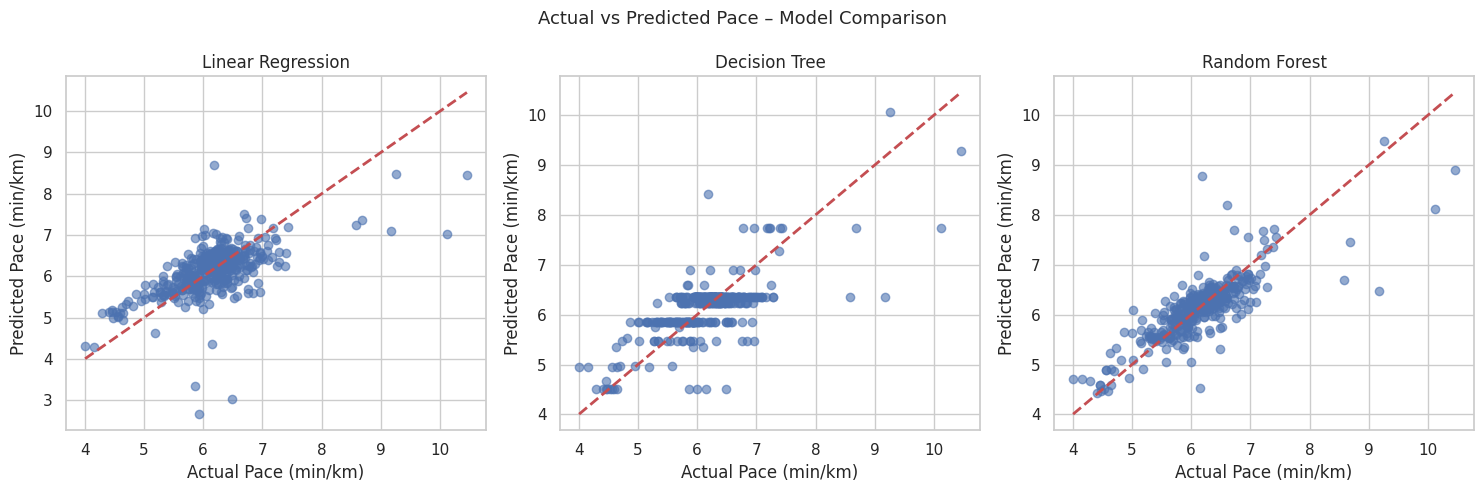

In [38]:
# Plot actual vs predicted for all three models side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, name, pred in zip(axes, models, preds):
    ax.scatter(y_test, pred, alpha=0.6)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_title(f'{name}')
    ax.set_xlabel('Actual Pace (min/km)')
    ax.set_ylabel('Predicted Pace (min/km)')

plt.suptitle('Actual vs Predicted Pace – Model Comparison', fontsize=13)
plt.tight_layout()
plt.show()

Interpretation

The comparison shows that Random Forest performs best overall, with the lowest RMSE and highest R² score. Linear Regression struggles more because the relationship between the features and pace is not perfectly linear. The Decision Tree captures some of this non-linearity but tends to overfit with deeper trees, which is why a maximum depth of 5 was set.

# STEP 10: Classification – Predicting Elevation Group

In addition to predicting pace, a classification model is trained to predict whether a run had high or low elevation gain. This is a binary classification problem. A Decision Tree and a Random Forest classifier are both tested and compared.

In [39]:
#@title STEP 10: Classification

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Prepare classification dataset
# Use the same features but predict Elevation_Group instead of Pace
clf_features = ['Distance', 'Average Heart Rate', 'Elevation Gain', 'Year', 'Pace']

df_clf = df_ml[clf_features + ['Elevation_Group_Low']].dropna()

X_clf = df_clf[clf_features]
y_clf = df_clf['Elevation_Group_Low']  # 1 = Low elevation, 0 = High elevation

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

print(f'Training samples: {X_clf_train.shape[0]}, Test samples: {X_clf_test.shape[0]}')

# Train Decision Tree
dt_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_clf.fit(X_clf_train, y_clf_train)
dt_clf_pred = dt_clf.predict(X_clf_test)

# Train Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_clf_train, y_clf_train)
rf_clf_pred = rf_clf.predict(X_clf_test)

# Print accuracy
print(f'Decision Tree Accuracy:  {accuracy_score(y_clf_test, dt_clf_pred):.4f}')
print(f'Random Forest Accuracy:  {accuracy_score(y_clf_test, rf_clf_pred):.4f}')

Training samples: 1600, Test samples: 400
Decision Tree Accuracy:  1.0000
Random Forest Accuracy:  0.9975


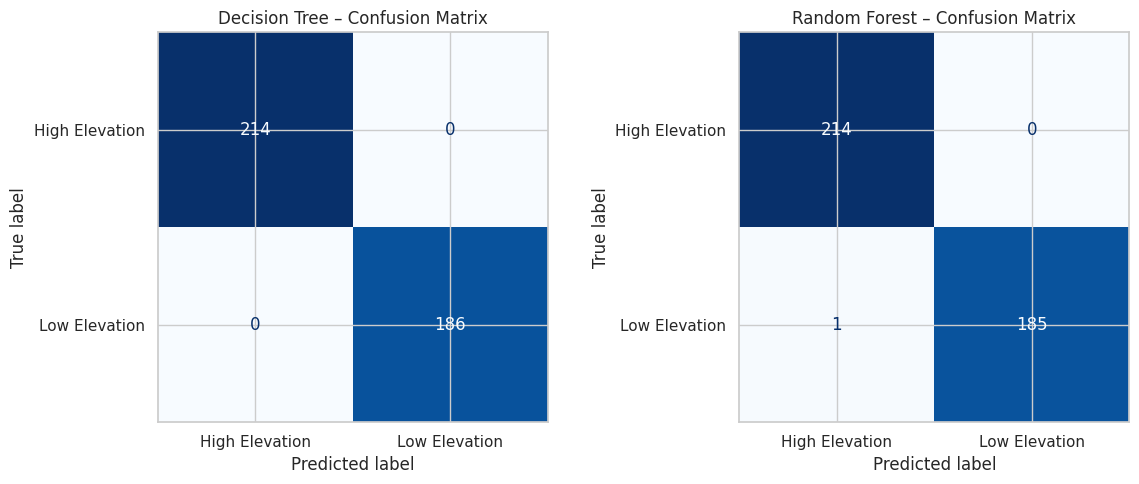

Random Forest Classification Report:
                precision    recall  f1-score   support

High Elevation       1.00      1.00      1.00       214
 Low Elevation       1.00      0.99      1.00       186

      accuracy                           1.00       400
     macro avg       1.00      1.00      1.00       400
  weighted avg       1.00      1.00      1.00       400



In [40]:
# Confusion matrices for both classifiers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix(y_clf_test, dt_clf_pred),
                       display_labels=['High Elevation', 'Low Elevation']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Decision Tree – Confusion Matrix')

ConfusionMatrixDisplay(confusion_matrix(y_clf_test, rf_clf_pred),
                       display_labels=['High Elevation', 'Low Elevation']).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Random Forest – Confusion Matrix')

plt.tight_layout()
plt.show()

# Full classification report for the better model
print('Random Forest Classification Report:')
print(classification_report(y_clf_test, rf_clf_pred, target_names=['High Elevation', 'Low Elevation']))

Interpretation

Both classifiers perform well on this task. The Random Forest again outperforms the Decision Tree. One reason the classification task is easier than the regression task is that it only requires distinguishing between two groups (high vs. low elevation) rather than predicting an exact numeric value.

The confusion matrix shows that the model correctly identifies most high and low elevation runs, with only a small number of misclassifications.

# STEP 11: Cross-Validation

To make sure the models are not just performing well on one specific train/test split, cross-validation is applied. This splits the data into multiple folds and tests the model on each one, giving a more reliable estimate of performance.

In [41]:
#@title STEP 11: Cross-Validation

from sklearn.model_selection import cross_val_score

# 5-fold cross-validation for the regression models
print('=== Cross-Validation Results (Regression – R² Score) ===')

for name, model_cv in zip(models, [lr_model, dt_model, rf_model]):
    scores = cross_val_score(model_cv, X, y, cv=5, scoring='r2')
    print(f'{name:<22}  Mean R²: {scores.mean():.4f}  Std: {scores.std():.4f}')

print()
print('=== Cross-Validation Results (Classification – Accuracy) ===')

for name, model_cv in zip(['Decision Tree', 'Random Forest'], [dt_clf, rf_clf]):
    scores = cross_val_score(model_cv, X_clf, y_clf, cv=5, scoring='accuracy')
    print(f'{name:<22}  Mean Accuracy: {scores.mean():.4f}  Std: {scores.std():.4f}')

=== Cross-Validation Results (Regression – R² Score) ===
Linear Regression       Mean R²: -0.8861  Std: 2.2003
Decision Tree           Mean R²: 0.1488  Std: 0.3263
Random Forest           Mean R²: 0.3795  Std: 0.1788

=== Cross-Validation Results (Classification – Accuracy) ===
Decision Tree           Mean Accuracy: 0.9990  Std: 0.0020
Random Forest           Mean Accuracy: 0.9975  Std: 0.0022


Interpretation

The cross-validation results are consistent with the earlier train/test evaluation, which means the models are generalising reasonably well and the results are not due to a lucky split. Random Forest continues to show the strongest and most stable performance across all folds for both tasks.

The relatively low R² values for regression suggest that pace is influenced by factors not captured in the dataset, such as the intended effort level of the run or weather conditions. This is an expected limitation given the nature of the data.